# The APS 120 Card Game

In the latest episode of the fantastic podcast A Problem Squared (APS 120), co-host Matt Parker discusses a Solitaire-like card game one of the listeners sent in.

The rules of the game are quite simple:

1. Start with a shuffled deck
2. Draw cards one by one from the deck and put them down in a row on the table
3. After each draw, check if you have at least 4 cards in the row, if so and if
   - the 1st and 4th cards (from the end) have the same suit: remove the 2nd and 3rd cards (and check the remaining cards again)
   - the 1st and 4th cards (from the end) have the same rank: remove all 4 cards (and check the remaining cards again)
4. This repeats until the deck is empty, you win if there are 0 remaining cards on the table

Calling this a game might be a bit generous, since the player can take absolutely no independent actions once the deck is shuffled. But that makes it perfect for simulating individual runs and analysing the outcomes.

### Game Implementation

First, let's implement the game mechanics. We will use `numba` in order to compile and speed up the code.

In [1]:
import dask.array as da
import matplotlib.pyplot as plt
import numba
import numpy as np
import numpy.typing as npt
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

# set figure size and style
plt.rcParams["figure.figsize"] = (12, 8)
sns.set_style("whitegrid")
sns.set_palette("YlOrRd")

In [2]:
@numba.njit(cache=True)
def create_deck(
    num_suits: int,
    num_ranks: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Creates a deck as a list of two 1D NumPy."""
    deck_size = num_suits * num_ranks
    ranks = np.empty(deck_size, dtype=np.int8)
    suits = np.empty(deck_size, dtype=np.int8)
    i = 0
    for suit in range(num_suits):
        for rank in range(num_ranks):
            ranks[i] = rank
            suits[i] = suit
            i += 1
    return ranks, suits


@numba.njit(cache=True)
def shuffle_deck(
    fresh_deck: tuple[np.ndarray, np.ndarray],
) -> tuple[np.ndarray, np.ndarray]:
    """Returns a shuffled copy of the deck."""
    fresh_ranks, fresh_suits = fresh_deck
    indices = np.arange(fresh_ranks.shape[0])
    np.random.shuffle(indices)
    shuffled_ranks = fresh_ranks[indices]
    shuffled_suits = fresh_suits[indices]
    return shuffled_ranks, shuffled_suits


@numba.njit(cache=True)
def play_game(deck: tuple[np.ndarray, np.ndarray]) -> int:
    """Simulate a single game and return the number of remaining cards."""
    ranks, suits = deck
    deck_size = ranks.shape[0]

    # allocate an array for the 'table' cards (which can be at most be deck_size)
    # and a pointer to keep track of the current head of the table
    table_ranks = np.empty(deck_size, dtype=np.int8)
    table_suits = np.empty(deck_size, dtype=np.int8)
    pointer = 0

    # deal cards one by one
    for i in range(deck_size):
        # add the next card to the table
        table_ranks[pointer] = ranks[i]
        table_suits[pointer] = suits[i]
        pointer += 1

        while pointer >= 4:
            # compare suits
            if table_suits[pointer - 1] == table_suits[pointer - 4]:
                # remove second and third last cards by shifting last card down
                # and removing last two cards
                table_ranks[pointer - 3] = table_ranks[pointer - 1]
                table_suits[pointer - 3] = table_suits[pointer - 1]
                pointer -= 2

            # compare ranks
            elif table_ranks[pointer - 1] == table_ranks[pointer - 4]:
                # remove last four cards
                pointer -= 4
            else:
                break  # no match, exit inner loop, continue dealing

    return pointer  # remaining cards


@numba.njit(cache=True, parallel=True)
def simulation_loop(
    num_simulations: int,
    fresh_deck: tuple[np.ndarray, np.ndarray],
    dtype: npt.DTypeLike = np.int16,
) -> np.ndarray:
    """Runs simulations in parallel and returns a flat array of all outcomes."""

    # preallocate results array, one entry per simulation
    results = np.empty(num_simulations, dtype=dtype)

    # use prange to parallelize the loop
    for i in numba.prange(num_simulations):
        # shuffle a fresh copy of the deck
        shuffled_deck = shuffle_deck(fresh_deck)

        # store outcome in results array
        results[i] = play_game(shuffled_deck)
    return results


def run_simulations(
    num_simulations: int = 10_000,
    num_suits: int = 4,
    num_ranks: int = 13,
    return_raw_data: bool = False,
    dtype: npt.DTypeLike = np.int16,
) -> pd.DataFrame | np.ndarray:
    """Wrapper to run and process simulations."""

    # create base deck
    fresh_deck = create_deck(num_suits, num_ranks)

    # run simulations
    all_outcomes_array = simulation_loop(num_simulations, fresh_deck, dtype=dtype)

    # if return_raw_data, return outcomes as a flat array
    if return_raw_data:
        return all_outcomes_array

    # otherwise, process outcomes into probability histogram and return as DataFrame
    else:
        # count the occurrences of each unique outcome
        unique_outcomes, counts = np.unique(all_outcomes_array, return_counts=True)

        # convert the counts to probabilities and format into a dataframe
        outcomes = {
            outcome: count / num_simulations
            for outcome, count in zip(unique_outcomes, counts)
        }

        # convert to pandas DataFrame for easier plotting
        outcomes = pd.DataFrame(
            list(outcomes.items()),
            columns=["Remaining Cards", "Probability"],
        )

        return outcomes

### Running 10 Million Games

First, let's recreate Matt's analysis to see if nothing went wrong in setting up the simulations


In [3]:
%%time

# Run 10 million simulations with standard 52-card deck
outcomes = run_simulations(num_simulations=int(1e7), num_suits=4, num_ranks=13)

CPU times: user 19.3 s, sys: 50.4 ms, total: 19.4 s
Wall time: 3.24 s


<Axes: xlabel='Remaining Cards', ylabel='Probability'>

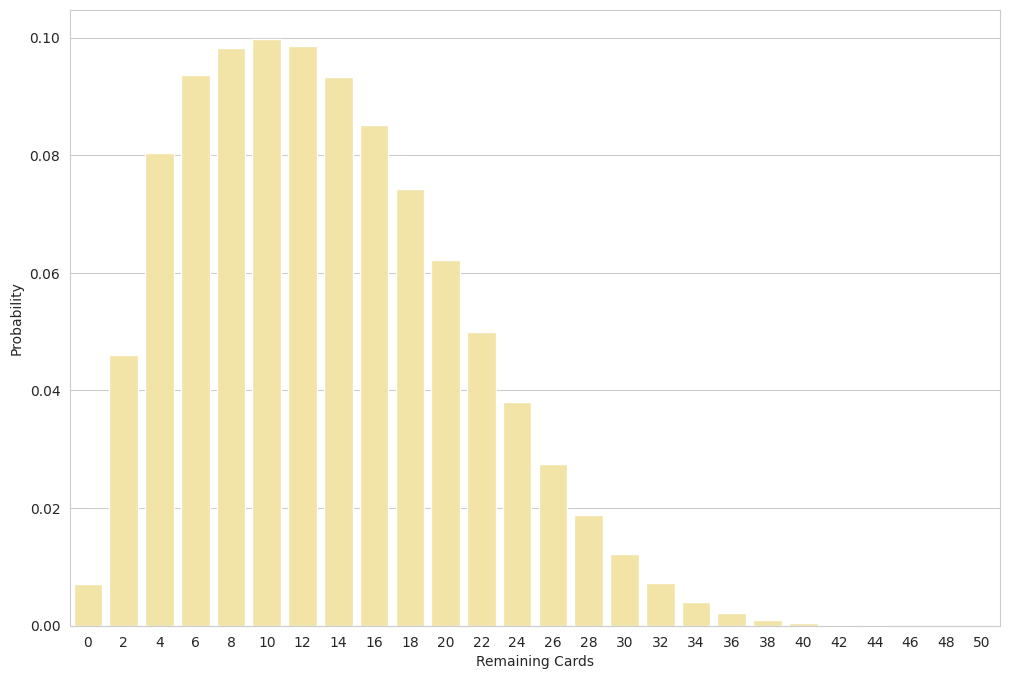

In [4]:
# Plotting the results
sns.barplot(
    data=outcomes,
    x="Remaining Cards",
    y="Probability",
)

This looks very much like the graph Matt produced. The main outcome Matt was looking for is the probability of winning the game, i.e. having 0 remaining cards. He got a value of 0.707%. So let's check if we geta similar value.

In [5]:
print(
    f"Probability of winning the game (0 remaining cards): {outcomes.loc[outcomes['Remaining Cards'] == 0, 'Probability'].values[0]:.6%}"
)

Probability of winning the game (0 remaining cards): 0.706700%


Yeah, that value is reasonably close, although not quite the same. That could be caused by random variations though. Matt's hypothesis was that the winning value converges towards $1/\sqrt{2}$. I have my doubts about that, since the winning probability are likely depended on the number of suits and ranks, and our normal card deck is just a random combination of those values. But let's check that.

### Probability Of Winning

Let's run a huge number of simulations and track the outcome of each simulation directly. With the `return_raw_data`, we can an array of the remaining cards for each individual game, rather than the summarised histogram.

In [6]:
num_simulations = int(1e9)

outcomes = run_simulations(
    num_simulations=num_simulations,
    num_suits=4,
    num_ranks=13,
    return_raw_data=True,
    dtype=np.int8,
)

Now we can calculate the winning probability from this data set. To get a handle on the uncertainty of this value, we use bootstrapping: We resample (with replacement) from the outcome array, and treat these resampled arrays like independent simulation runs. (Of course, we could simply re-run the simulations multiple times, but that takes a lot longer.) We use dask to do the bootstrapping without completely breaking our memory. As a bonus, we can also calculate the probability of having all 52 cards remaining at the end of the game.

In [ ]:
# Calculate winning probability and its uncertainty using bootstrapping
num_bootstrap_samples = 100

winning_probabilities = []
all_cards_remaining_probabilities = []
for _ in tqdm(range(num_bootstrap_samples), desc="Bootstrapping"):
    # resample with replacement
    resampled_outcomes = da.random.choice(
        outcomes,
        size=num_simulations,
        replace=True,
        chunks="auto",  # chunk array so it fits in memory
    ).compute()

    # calculate probabilities
    winning_probability = np.sum(resampled_outcomes == 0) / num_simulations
    all_cards_remaining_probability = np.sum(resampled_outcomes == 52) / num_simulations
    winning_probabilities.append(winning_probability)
    all_cards_remaining_probabilities.append(all_cards_remaining_probability)

winning_probabilities = np.array(winning_probabilities)
all_cards_remaining_probabilities = np.array(all_cards_remaining_probabilities)

Bootstrapping:   0%|          | 0/100 [00:00<?, ?it/s]

In [94]:
# Now we have a list of winning probabilities from the bootstrap samples
winning_probabilities_percentage = np.array(winning_probabilities) * 100  # percentage
rel_deviations_from_1_sqrt_2_percentage = (
    np.abs(winning_probabilities_percentage - 1 / np.sqrt(2)) / (1 / np.sqrt(2)) * 100
)

all_cards_remaining_probabilities_percentage = (
    np.array(all_cards_remaining_probabilities) * 100
)  # percentage

Winning Probability: (0.7059 ± 0.0003)% (95% CI: 0.0070538 - 0.0070639)
Relative deviation from 1/sqrt(2): (0.1763 ± 0.04)% (95% CI: 0.0010157 - 0.0024489)
Expected number of games to win: 141.67


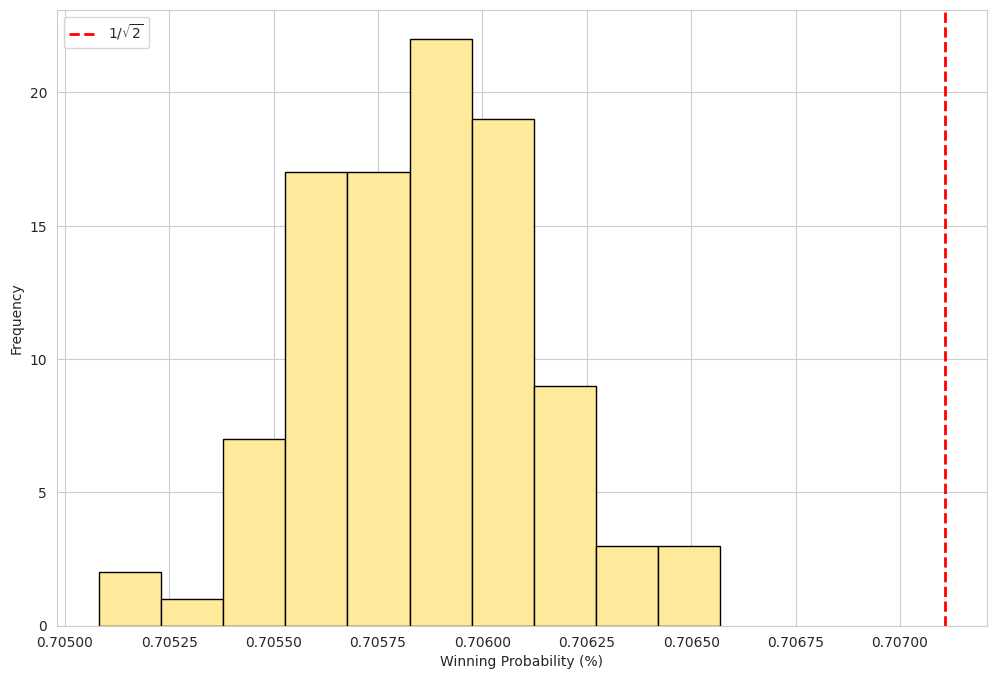

In [116]:
print(
    f"Winning Probability: ({np.mean(winning_probabilities_percentage):.4} ± {np.std(winning_probabilities_percentage):.1})% "
    f"(95% CI: {np.percentile(winning_probabilities_percentage/100, 2.5):.5} - {np.percentile(winning_probabilities_percentage/100, 97.5):.5})"
)

print(
    f"Relative deviation from 1/sqrt(2): ({np.abs(np.mean(rel_deviations_from_1_sqrt_2_percentage)):.4} ± {np.std(rel_deviations_from_1_sqrt_2_percentage):.1})% "
    f"(95% CI: {np.percentile(rel_deviations_from_1_sqrt_2_percentage/100, 2.5):.5} - {np.percentile(rel_deviations_from_1_sqrt_2_percentage/100, 97.5):.5})"
)
print(f"Expected number of games to win: {1/np.mean(winning_probabilities):.2f}")

plt.hist(
    winning_probabilities_percentage,
    bins="fd",
    edgecolor="black",
)
plt.axvline(
    1 / np.sqrt(2),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=r"1/$\sqrt{2}$",
)
plt.xlabel("Winning Probability (%)")
plt.ylabel("Frequency")
plt.legend()

Probability of finishing with all 52 cards remaining: (0.0000047 ± 0.0000007)% (95% CI: 0.00000 - 0.00000)
Expected number of games to get all cards remaining: 21 million


Text(0, 0.5, 'Frequency')

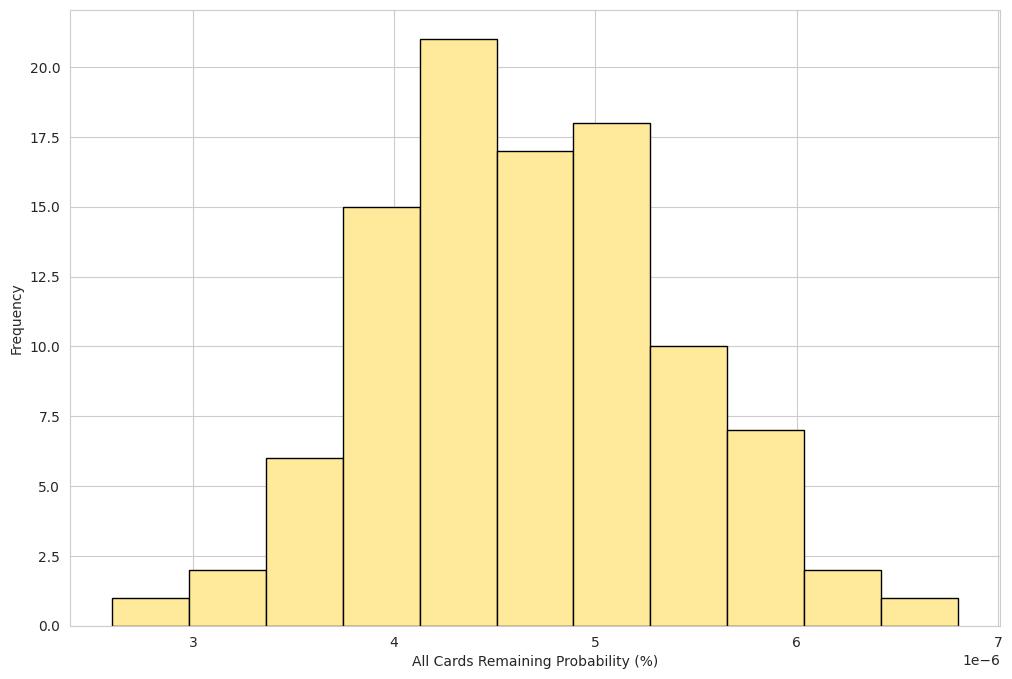

In [120]:
print(
    f"Probability of finishing with all 52 cards remaining: ({np.mean(all_cards_remaining_probabilities_percentage):.7f} ± {np.std(all_cards_remaining_probabilities_percentage):.7f})% "
    f"(95% CI: {np.percentile(all_cards_remaining_probabilities_percentage/100, 2.5):.5f} - {np.percentile(all_cards_remaining_probabilities_percentage/100, 97.5):.5f})"
)
print(
    f"Expected number of games to get all cards remaining: {1/np.mean(all_cards_remaining_probabilities) *1e-6:.0f} million"
)

plt.hist(
    all_cards_remaining_probabilities_percentage,
    bins="fd",
    edgecolor="black",
)
plt.xlabel("All Cards Remaining Probability (%)")
plt.ylabel("Frequency")

Sp this means that the winning probability deviates from $1/\sqrt{2}$ by about **0.18%**. That's really damn close! But from the bootstrapping, we can quite confidently rule out that the value coincides with $1/\sqrt{2}$.

We can also see that the average number of games you'd need to play to have all 52 remaining at the end of the game is around **21 million**, which is **150 thousand** times less likely than to win the game.

We can have a bit more fun as well. Now that it's all coded up, we can check the winning probability as a function of the number of suits and ranks in the deck. If the value for 4 suits and 13 ranks really was $1/\sqrt{2}$, I'd assume there is some pattern visible in that distribution as well. Let's see.

### Parameter Sweep Across Cifferent Deck Configurations

We'll test the game with different numbers of suits and ranks to see how they affect the winning probability. We'll sweep through:

- **Suits**: 2, 3, 4, 5,
- **Ranks**: 4, 7, 10, 13, 16

For each combination, we'll run 1 million simulations to get somewhat reliable statistics.

In [173]:
# define parameter ranges
suit_values = [3, 4, 5, 6, 7]
rank_values = [9, 10, 11, 12, 13, 14, 15]

# get combinations of values
param_combinations = [(suits, ranks) for suits in suit_values for ranks in rank_values]

print(f"Running simulations for {len(param_combinations)} parameter combinations.")

num_simulations = int(1e7)

results = {}
for num_suits, num_ranks in tqdm(param_combinations, desc="Parameter combinations"):
    # run simulations
    outcomes = run_simulations(
        num_simulations=num_simulations,
        num_suits=num_suits,
        num_ranks=num_ranks,
    )

    # extract winning probability, accounting for case of zero wins
    try:
        winning_probability_percentages = (
            outcomes.loc[outcomes["Remaining Cards"] == 0, "Probability"].values[0]
            * 100
        )
    except IndexError:
        winning_probability_percentages = 0.0

    # store result
    results[(num_suits, num_ranks)] = winning_probability_percentages

Running simulations for 35 parameter combinations.


Parameter combinations:   0%|          | 0/35 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Winning Probability as Function of Deck Composition')

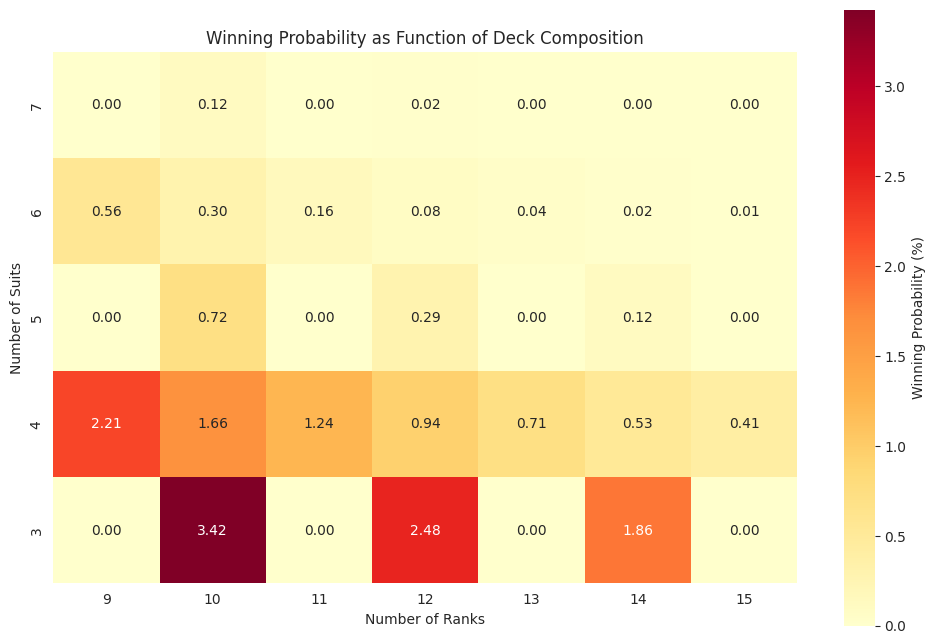

In [175]:
# Plot results as heatmap
heatmap_data = pd.DataFrame(
    index=suit_values,
    columns=rank_values,
)
for (num_suits, num_ranks), winning_probability in results.items():
    heatmap_data.at[num_suits, num_ranks] = winning_probability

sns.heatmap(
    heatmap_data.astype(float),
    annot=True,
    fmt=".2f",
    square=True,
    cmap="YlOrRd",
    cbar_kws={"label": "Winning Probability (%)"},
)

plt.gca().invert_yaxis()

plt.xlabel("Number of Ranks")
plt.ylabel("Number of Suits")
plt.title("Winning Probability as Function of Deck Composition")

Quite unsuprisingly, the winning probably decreases as the number of suits and ranks increases. There are just more ways for the game to go wrong, so fewer games end in 0 remaining cards. We can also see that if you have a odd number of suits and ranks, the game seemingly can't be finished with zero games.

Text(0.5, 1.0, 'At Least One Win Observed as Function of Deck Composition')

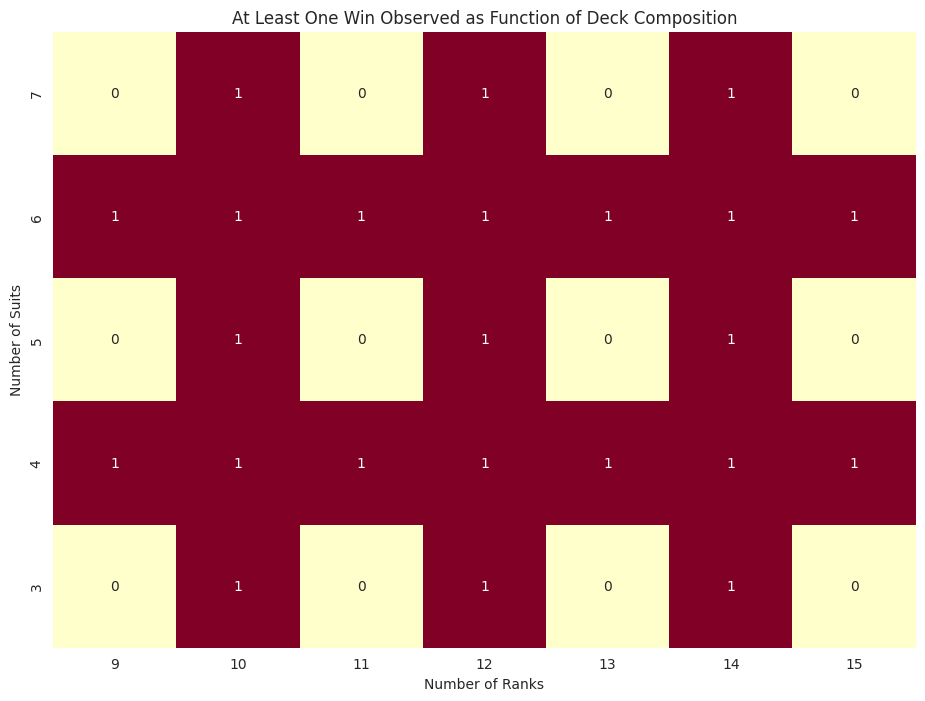

In [181]:
# Plot heatmap where if any wins were observed, mark as 1 else 0
heatmap_data_binary = pd.DataFrame(
    index=suit_values,
    columns=rank_values,
)
for (num_suits, num_ranks), winning_probability in results.items():
    heatmap_data_binary.at[num_suits, num_ranks] = 1 if winning_probability > 0 else 0
sns.heatmap(
    heatmap_data_binary.astype(float),
    annot=True,
    fmt=".0f",
    square=True,
    cmap="YlOrRd",
    cbar=False,
)
plt.gca().invert_yaxis()
plt.xlabel("Number of Ranks")
plt.ylabel("Number of Suits")
plt.title("At Least One Win Observed as Function of Deck Composition")